# E-Commerce Customer Behavior Case Study

**Goal:** Analyze customer journey, identify funnel drop-offs, and deliver evidence-based business recommendations.

**Dataset:** `events.csv` — ~885,000 rows of user event data (view / cart / purchase)

**Workflow:** Business Understanding → Data Cleaning → KPI Calculation → Funnel Analysis → EDA → Segmentation → Dashboard → Recommendations

---
## 1. Business Understanding

**Business problem:** An e-commerce company sees many product views but low purchase completion. Management wants to know:
- Where do customers drop off in the funnel?
- Which products and brands perform best?
- What actions can improve sales?

**Analyst goal:** Turn raw event data into clear, evidence-backed decisions.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def fmt_currency(x): return f'${x:,.2f}'
def fmt_percent(x):  return f'{x:.2%}'
def fmt_int(x):      return f'{int(x):,}'

print('Setup complete.')

Setup complete.


---
## 2. Load Data

In [2]:
DATA_PATH = r'D:\Data Analyst Bootcamp\assignment\events.csv'

raw = pd.read_csv(DATA_PATH)
raw['event_time'] = pd.to_datetime(raw['event_time'], errors='coerce')

print(f'Rows: {len(raw):,}  |  Columns: {raw.shape[1]}')
display(raw.head(3))

print('\nData types:')
print(raw.dtypes)

Rows: 885,129  |  Columns: 9


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy



Data types:
event_time       datetime64[us, UTC]
event_type                       str
product_id                     int64
category_id                    int64
category_code                    str
brand                            str
price                        float64
user_id                        int64
user_session                     str
dtype: object


---
## 3. Data Cleaning

Cleaning checklist:
- Remove duplicate rows
- Drop rows with null `event_time` or `user_id`
- Fill missing prices with 0 (unknown price, not free — flag for review)
- Fill missing brand / category with `'unknown'`
- Extract time features (month, hour, day of week)
- Document every decision

In [3]:
before = len(raw)
clean = raw.drop_duplicates().copy()
after_dedup = len(clean)

clean = clean.dropna(subset=['event_time', 'user_id'])
after_nulls = len(clean)

clean['price'] = clean['price'].fillna(0)
clean['brand'] = clean['brand'].fillna('unknown')
clean['category_code'] = clean['category_code'].fillna('unknown')

# Extract time features
clean['event_month']   = clean['event_time'].dt.to_period('M').astype(str)
clean['event_hour']    = clean['event_time'].dt.hour
clean['event_dow']     = clean['event_time'].dt.day_name()
clean['event_date']    = clean['event_time'].dt.date

# Top-level category
clean['category_top'] = clean['category_code'].str.split('.').str[0]

print('=== Data Quality Summary ===')
print(f'  Original rows        : {fmt_int(before)}')
print(f'  After deduplication  : {fmt_int(after_dedup)}  ({before - after_dedup:,} duplicates removed)')
print(f'  After null drop      : {fmt_int(after_nulls)}  ({after_dedup - after_nulls:,} rows dropped)')
print(f'  Missing brand filled : {(raw["brand"].isna().sum()):,} rows → "unknown"')
print(f'  Missing category     : {(raw["category_code"].isna().sum()):,} rows → "unknown"')
print(f'  Missing price        : {(raw["price"].isna().sum()):,} rows → 0')
print(f'  Final clean rows     : {fmt_int(len(clean))}')

clean.to_csv(OUTPUT_DIR / 'events_cleaned.csv', index=False)
print('\nevents_cleaned.csv saved.')

=== Data Quality Summary ===
  Original rows        : 885,129
  After deduplication  : 884,474  (655 duplicates removed)
  After null drop      : 884,474  (0 rows dropped)
  Missing brand filled : 212,364 rows → "unknown"
  Missing category     : 236,219 rows → "unknown"
  Missing price        : 0 rows → 0
  Final clean rows     : 884,474

events_cleaned.csv saved.


---
## 4. KPI Summary

In [4]:
purchase_df = clean[clean['event_type'] == 'purchase']
cart_df     = clean[clean['event_type'] == 'cart']
view_df     = clean[clean['event_type'] == 'view']

total_users        = clean['user_id'].nunique()
total_sessions     = clean['user_session'].nunique()
total_views        = len(view_df)
total_purchases    = len(purchase_df)
total_revenue      = purchase_df['price'].sum()
aov                = total_revenue / total_purchases if total_purchases else 0
purchasing_users   = purchase_df['user_id'].nunique()
overall_conversion = purchasing_users / total_users

kpi = pd.DataFrame([
    ['Total Users',          fmt_int(total_users)],
    ['Total Sessions',       fmt_int(total_sessions)],
    ['Total Product Views',  fmt_int(total_views)],
    ['Total Purchases',      fmt_int(total_purchases)],
    ['Total Revenue',        fmt_currency(total_revenue)],
    ['Average Order Value',  fmt_currency(aov)],
    ['Overall Conversion Rate', fmt_percent(overall_conversion)],
], columns=['KPI', 'Value'])

display(kpi)
kpi.to_csv(OUTPUT_DIR / 'kpi_summary.csv', index=False)
print('kpi_summary.csv saved.')

,KPI,Value
0,Total Users,"407,283"
1,Total Sessions,"490,398"
2,Total Product Views,"793,099"
3,Total Purchases,"37,343"
4,Total Revenue,"$5,125,113.92"
5,Average Order Value,$137.24
6,Overall Conversion Rate,5.23%


kpi_summary.csv saved.


---
## 5. Funnel Analysis

**Most important concept:** Where in the journey do users leave?

,Stage,Users,Drop-off %,Conversion
0,View,406863,NaN,—
1,Cart,36952,90.9%,9.08%
2,Purchase,21304,42.3%,57.65%


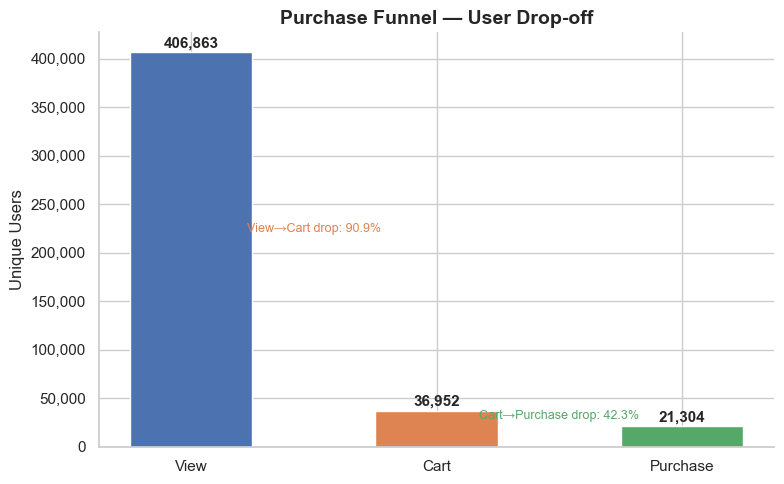

funnel_summary.csv saved.

INSIGHT: Largest drop-off is View → Cart (90.9% of viewers never add to cart).
   This is the highest-impact optimization point.


In [5]:
view_users     = view_df['user_id'].nunique()
cart_users     = cart_df['user_id'].nunique()
purchase_users = purchase_df['user_id'].nunique()

v2c_rate = cart_users / view_users          # view → cart
c2p_rate = purchase_users / cart_users      # cart → purchase
overall  = purchase_users / view_users      # overall

funnel = pd.DataFrame({
    'Stage':       ['View', 'Cart', 'Purchase'],
    'Users':       [view_users, cart_users, purchase_users],
    'Drop-off %':  [None, f'{(1 - v2c_rate):.1%}', f'{(1 - c2p_rate):.1%}'],
    'Conversion':  ['—', fmt_percent(v2c_rate), fmt_percent(c2p_rate)],
})
display(funnel)

# Funnel bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(['View', 'Cart', 'Purchase'],
              [view_users, cart_users, purchase_users],
              color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, [view_users, cart_users, purchase_users]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Annotate drop-offs
ax.annotate(f'View→Cart drop: {(1-v2c_rate):.1%}',
            xy=(0.5, (view_users + cart_users) / 2),
            fontsize=9, color='#DD8452', ha='center')
ax.annotate(f'Cart→Purchase drop: {(1-c2p_rate):.1%}',
            xy=(1.5, (cart_users + purchase_users) / 2),
            fontsize=9, color='#55A868', ha='center')

ax.set_title('Purchase Funnel — User Drop-off', fontsize=14, fontweight='bold')
ax.set_ylabel('Unique Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'funnel_chart.png', dpi=150)
plt.show()

funnel.to_csv(OUTPUT_DIR / 'funnel_summary.csv', index=False)
print('funnel_summary.csv saved.')

print(f'\nINSIGHT: Largest drop-off is View → Cart ({(1-v2c_rate):.1%} of viewers never add to cart).')
print(f'   This is the highest-impact optimization point.')

---
## 6. Exploratory Data Analysis (EDA)

Explore patterns before building recommendations.

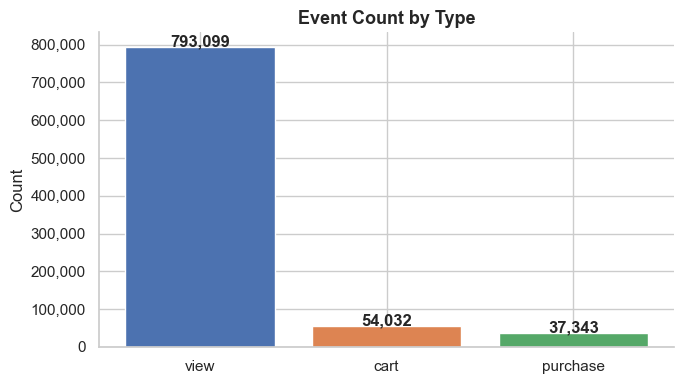

event_type
view        793099
cart         54032
purchase     37343


In [6]:
# 6a. Event type distribution
event_counts = clean['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colors_ec = ['#4C72B0', '#DD8452', '#55A868']
ax.bar(event_counts.index, event_counts.values, color=colors_ec, edgecolor='white')
for i, (label, val) in enumerate(event_counts.items()):
    ax.text(i, val + 2000, f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Event Count by Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'event_counts.png', dpi=150)
plt.show()
print(event_counts.to_string())

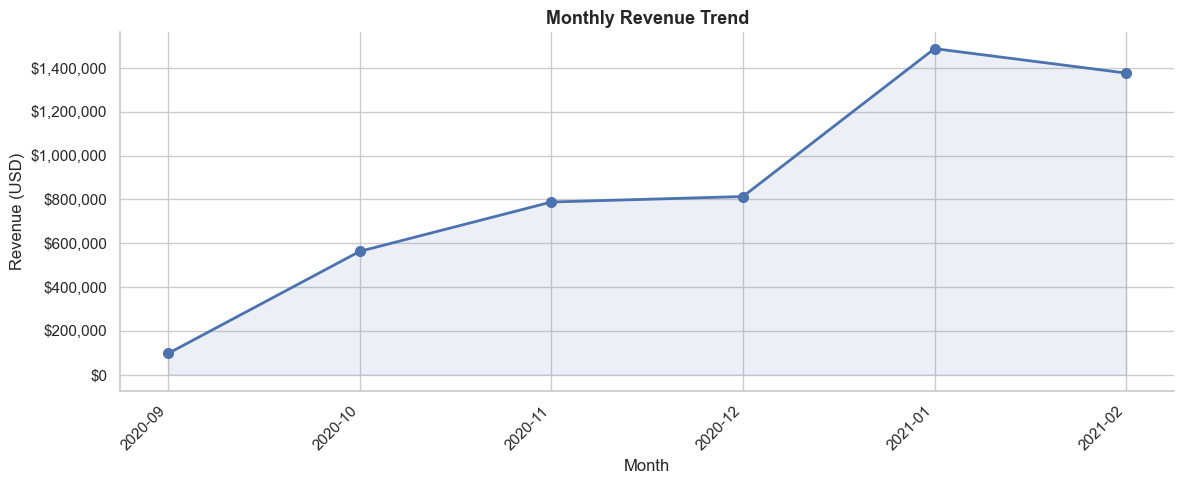

In [7]:
# 6b. Monthly revenue trend
monthly_rev = purchase_df.groupby('event_month')['price'].sum().reset_index()
monthly_rev.columns = ['Month', 'Revenue']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_rev['Month'], monthly_rev['Revenue'],
        marker='o', linewidth=2, color='#4C72B0', markersize=7)
ax.fill_between(monthly_rev['Month'], monthly_rev['Revenue'], alpha=0.1, color='#4C72B0')
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (USD)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_revenue.png', dpi=150)
plt.show()

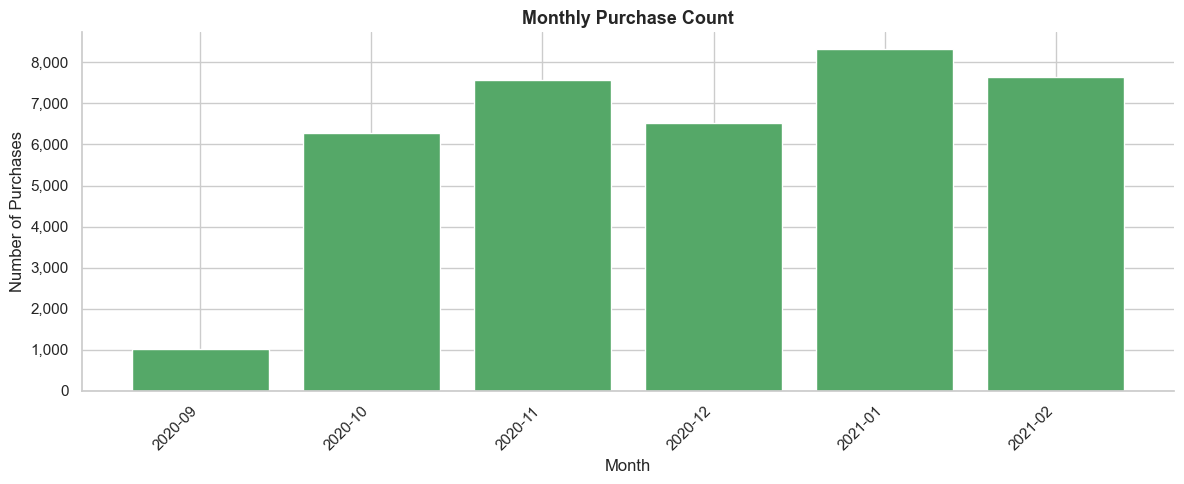

In [8]:
# 6c. Monthly purchases count
monthly_purchases = purchase_df.groupby('event_month').size().reset_index(name='Purchases')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_purchases['event_month'], monthly_purchases['Purchases'],
       color='#55A868', edgecolor='white')
ax.set_title('Monthly Purchase Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Purchases')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_purchases.png', dpi=150)
plt.show()

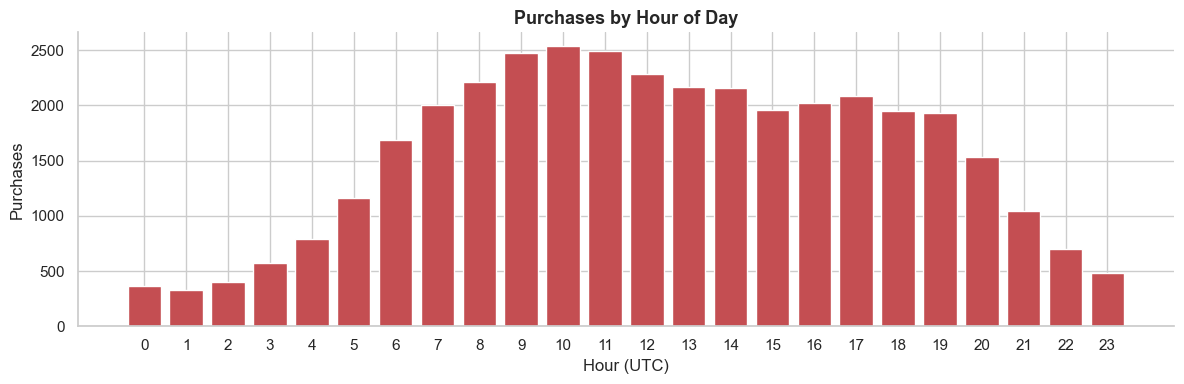

In [9]:
# 6d. Purchases by hour of day
hourly = purchase_df.groupby('event_hour').size().reset_index(name='purchases')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly['event_hour'], hourly['purchases'], color='#C44E52', edgecolor='white')
ax.set_title('Purchases by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Purchases')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hourly_purchases.png', dpi=150)
plt.show()

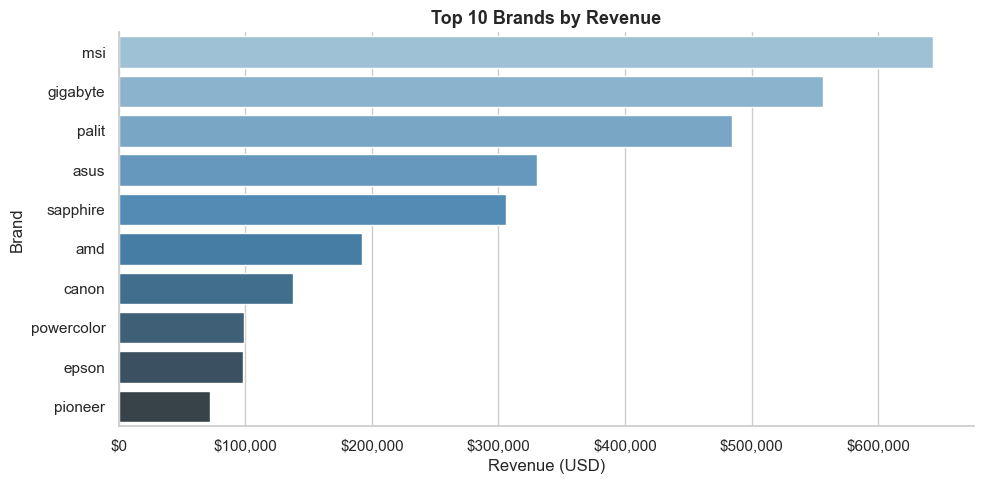

brand_revenue.csv saved.


,Brand,Revenue
0,msi,643492.34
1,gigabyte,556183.04
2,palit,484210.58
3,asus,330147.11
4,sapphire,306192.94
5,amd,191987.40
6,canon,137964.79
7,powercolor,98804.38
8,epson,98262.95
9,pioneer,72102.45


In [10]:
# 6e. Top 10 brands by revenue
brand_rev = (
    purchase_df[purchase_df['brand'] != 'unknown']
    .groupby('brand')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
brand_rev.columns = ['Brand', 'Revenue']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=brand_rev, y='Brand', x='Revenue', palette='Blues_d', ax=ax)
ax.set_title('Top 10 Brands by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'brand_revenue_chart.png', dpi=150)
plt.show()

brand_rev.to_csv(OUTPUT_DIR / 'brand_revenue.csv', index=False)
print('brand_revenue.csv saved.')
display(brand_rev)

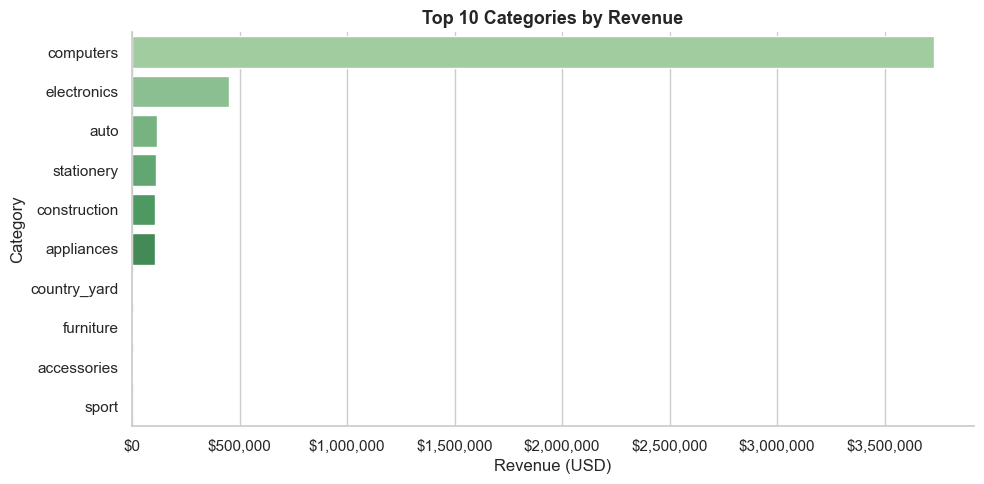

category_revenue.csv saved.


,Category,Revenue
0,computers,3728835.55
1,electronics,450348.57
2,auto,117312.54
3,stationery,109670.38
4,construction,108682.40
5,appliances,105299.99
6,country_yard,4339.47
7,furniture,2090.82
8,accessories,2084.41
9,sport,1706.40


In [11]:
# 6f. Top 10 categories by revenue
cat_rev = (
    purchase_df[purchase_df['category_top'] != 'unknown']
    .groupby('category_top')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
cat_rev.columns = ['Category', 'Revenue']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cat_rev, y='Category', x='Revenue', palette='Greens_d', ax=ax)
ax.set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_revenue_chart.png', dpi=150)
plt.show()

cat_rev.to_csv(OUTPUT_DIR / 'category_revenue.csv', index=False)
print('category_revenue.csv saved.')
display(cat_rev)

In [12]:
# 6g. Top 10 products by purchase count
top_products = (
    purchase_df.groupby('product_id')
    .agg(purchases=('event_type', 'count'), revenue=('price', 'sum'))
    .sort_values('purchases', ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)
top_products.to_csv(OUTPUT_DIR / 'product_purchases.csv', index=False)
print('product_purchases.csv saved.')

,product_id,purchases,revenue
0,4099645,564,165156.12
1,3829355,543,17495.46
2,1821813,538,213844.24
3,3791351,423,86414.67
4,893196,384,82214.40
5,3642540,345,9035.55
6,4102739,266,78313.06
7,287525,261,2440.35
8,4154414,257,52086.19
9,246841,242,7071.24


product_purchases.csv saved.


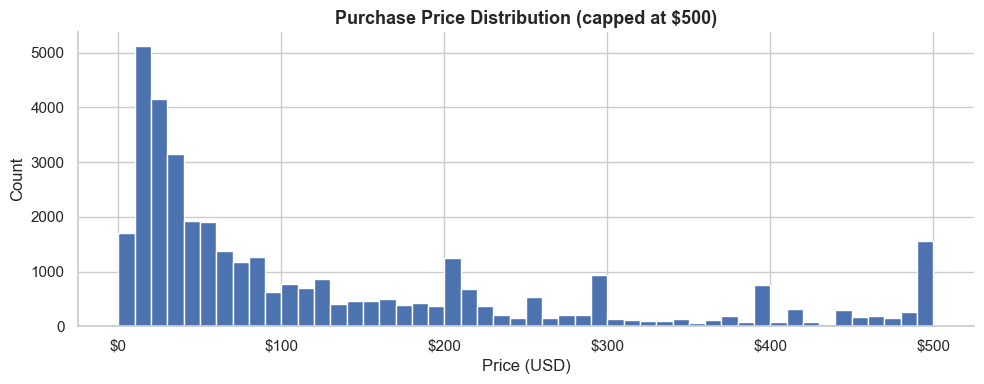

In [13]:
# 6h. Price distribution of purchases
fig, ax = plt.subplots(figsize=(10, 4))
purchase_df[purchase_df['price'] > 0]['price'].clip(upper=500).hist(
    bins=50, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Purchase Price Distribution (capped at $500)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'price_distribution.png', dpi=150)
plt.show()

---
## 7. Low-Conversion Products

Products with high views but low purchase rate — prime candidates for product page improvement.

In [14]:
product_views     = view_df.groupby('product_id').size().rename('views')
product_purchases = purchase_df.groupby('product_id').size().rename('purchases')

product_conv = pd.concat([product_views, product_purchases], axis=1).fillna(0)
product_conv['conversion_rate'] = product_conv['purchases'] / product_conv['views']

# High-traffic, low-conversion: at least 100 views, bottom 10% conversion
min_views = 100
threshold = product_conv[product_conv['views'] >= min_views]['conversion_rate'].quantile(0.10)

low_conv = (
    product_conv[
        (product_conv['views'] >= min_views) &
        (product_conv['conversion_rate'] <= threshold)
    ]
    .sort_values('views', ascending=False)
    .head(20)
    .reset_index()
)

low_conv['conversion_rate'] = low_conv['conversion_rate'].apply(fmt_percent)
display(low_conv)
low_conv.to_csv(OUTPUT_DIR / 'low_conversion_products.csv', index=False)
print('low_conversion_products.csv saved.')
print(f'\nINSIGHT: {len(low_conv)} high-traffic products have conversion below {fmt_percent(threshold)}.')
print('   Improving product pages for these could significantly lift overall revenue.')

,product_id,views,purchases,conversion_rate
0,229036,1150.0,0.0,0.00%
1,775032,1086.0,0.0,0.00%
2,83737,995.0,0.0,0.00%
3,1674260,946.0,0.0,0.00%
4,589968,891.0,0.0,0.00%
5,1255165,879.0,0.0,0.00%
6,698803,724.0,0.0,0.00%
7,261923,615.0,0.0,0.00%
8,3830671,610.0,0.0,0.00%
9,145379,513.0,0.0,0.00%


low_conversion_products.csv saved.

INSIGHT: 20 high-traffic products have conversion below 0.00%.
   Improving product pages for these could significantly lift overall revenue.


---
## 8. Customer Segmentation

Segmenting users by their behavior allows tailored business actions for each group.

,Segment,Users,% of Total Users,Business Action
0,Only Viewed,369083,90.62%,Improve product pages & discoverability
1,Cart Abandoned,16896,4.15%,Cart abandonment emails / checkout friction fix
2,Purchased Once,13598,3.34%,Cross-sell & related product recommendations
3,Repeat Buyers,7706,1.89%,Loyalty rewards & retention campaigns


user_segments.csv saved.


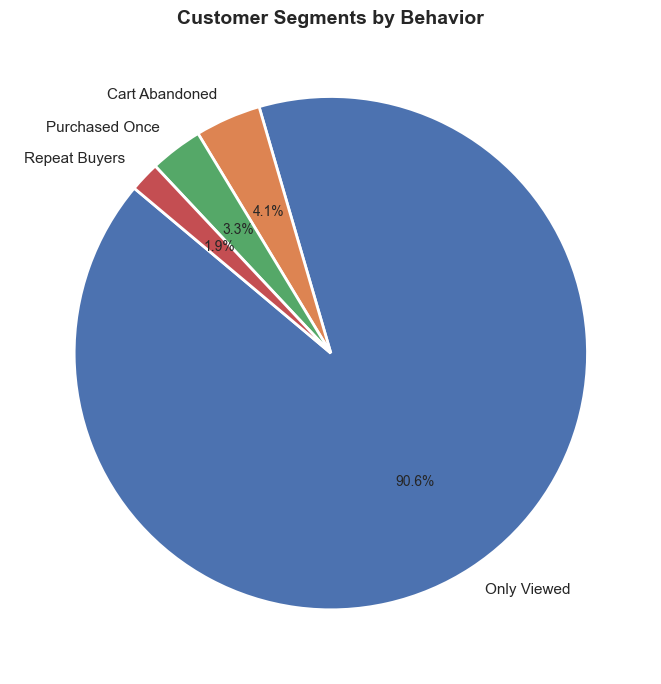

In [15]:
viewed_users   = set(view_df['user_id'])
carted_users   = set(cart_df['user_id'])
purchased_users = set(purchase_df['user_id'])

# Repeat buyers: purchased more than once
purchase_counts = purchase_df.groupby('user_id').size()
repeat_buyers   = set(purchase_counts[purchase_counts > 1].index)
one_time_buyers = purchased_users - repeat_buyers

segments = {
    'Only Viewed':      viewed_users - carted_users - purchased_users,
    'Cart Abandoned':   carted_users - purchased_users,
    'Purchased Once':   one_time_buyers,
    'Repeat Buyers':    repeat_buyers,
}

seg_df = pd.DataFrame([
    {
        'Segment': k,
        'Users': len(v),
        '% of Total Users': fmt_percent(len(v) / total_users),
        'Business Action': action
    }
    for (k, v), action in zip(segments.items(), [
        'Improve product pages & discoverability',
        'Cart abandonment emails / checkout friction fix',
        'Cross-sell & related product recommendations',
        'Loyalty rewards & retention campaigns',
    ])
])

display(seg_df)
seg_df.to_csv(OUTPUT_DIR / 'user_segments.csv', index=False)
print('user_segments.csv saved.')

# Pie chart
fig, ax = plt.subplots(figsize=(7, 7))
sizes   = [len(v) for v in segments.values()]
labels  = list(segments.keys())
colors_seg = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_seg, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts: t.set_fontsize(10)
ax.set_title('Customer Segments by Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'user_segments_pie.png', dpi=150)
plt.show()

---
## 9. Summary Dashboard

One-page KPI + funnel + top brands overview.

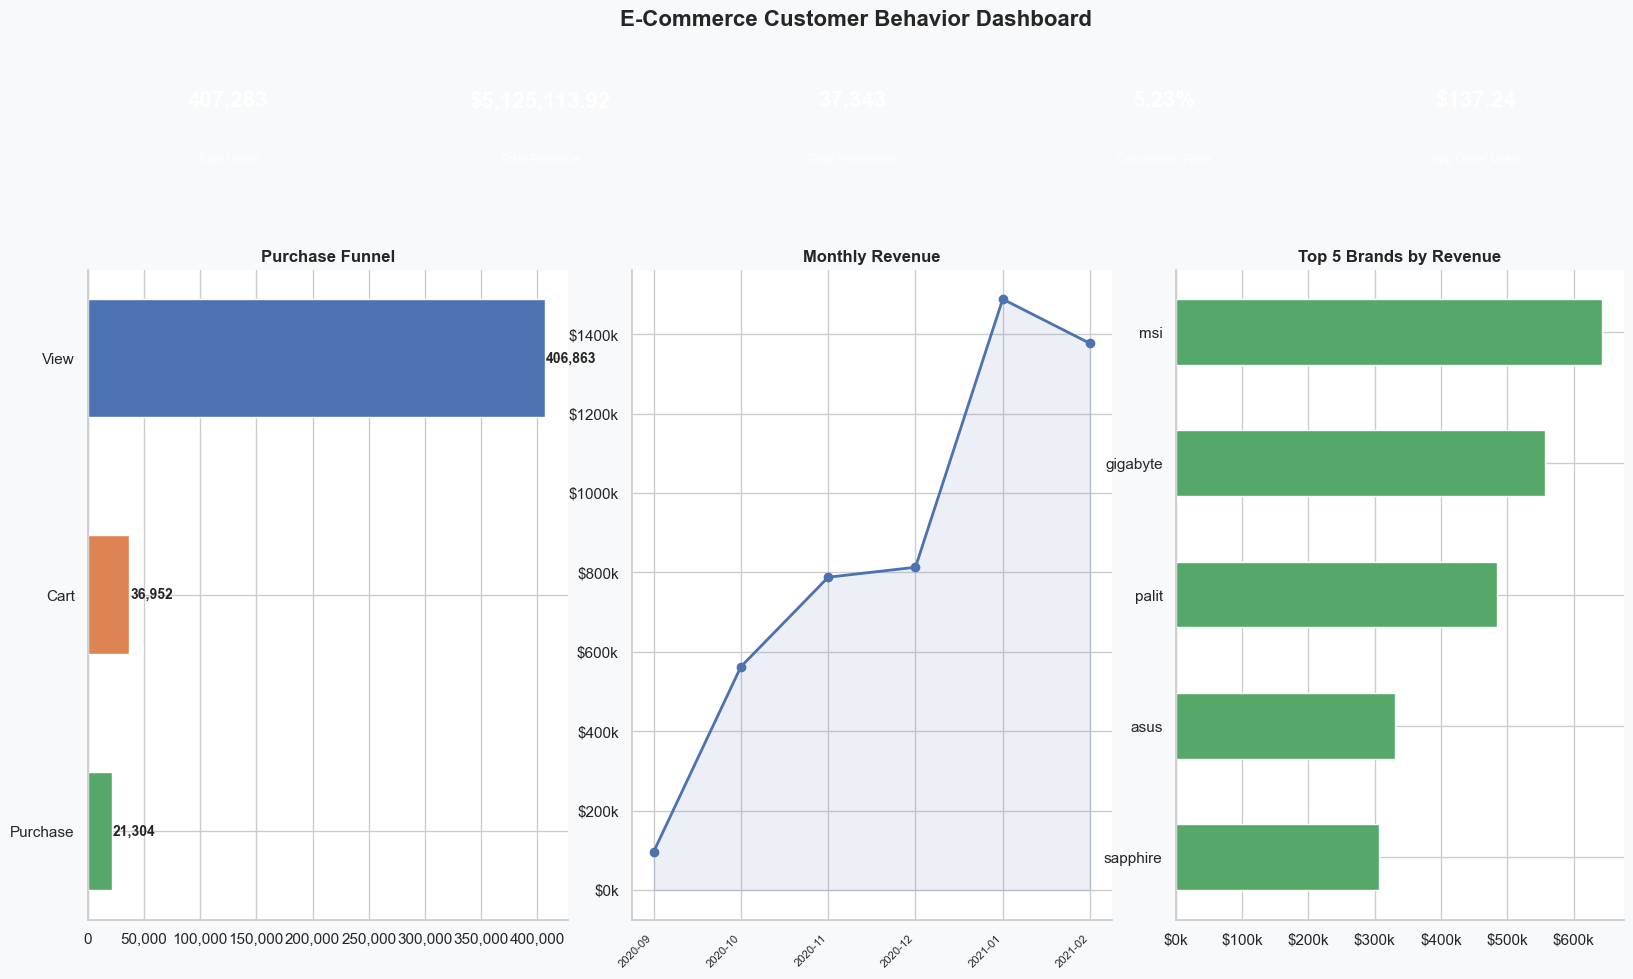

dashboard.png saved.


In [16]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')

# --- KPI Cards (top row) ---
kpi_data = [
    ('Total Users',     fmt_int(total_users),          '#4C72B0'),
    ('Total Revenue',   fmt_currency(total_revenue),   '#55A868'),
    ('Total Purchases', fmt_int(total_purchases),      '#DD8452'),
    ('Conversion Rate', fmt_percent(overall_conversion), '#C44E52'),
    ('Avg Order Value', fmt_currency(aov),              '#8172B2'),
]
for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_axes([0.02 + i * 0.195, 0.78, 0.175, 0.16])
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white')
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9)

# --- Funnel (bottom-left) ---
ax2 = fig.add_axes([0.02, 0.06, 0.30, 0.65])
ax2.set_facecolor('white')
funnel_vals  = [view_users, cart_users, purchase_users]
funnel_labels = ['View', 'Cart', 'Purchase']
funnel_colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax2.barh(funnel_labels[::-1], funnel_vals[::-1],
                color=funnel_colors[::-1], edgecolor='white', height=0.5)
for bar, val in zip(bars, funnel_vals[::-1]):
    ax2.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontweight='bold', fontsize=10)
ax2.set_title('Purchase Funnel', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.spines[['top', 'right']].set_visible(False)

# --- Monthly Revenue (bottom-center) ---
ax3 = fig.add_axes([0.36, 0.06, 0.30, 0.65])
ax3.set_facecolor('white')
ax3.plot(range(len(monthly_rev)), monthly_rev['Revenue'],
         marker='o', linewidth=2, color='#4C72B0')
ax3.fill_between(range(len(monthly_rev)), monthly_rev['Revenue'], alpha=0.1, color='#4C72B0')
ax3.set_title('Monthly Revenue', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(monthly_rev)))
ax3.set_xticklabels(monthly_rev['Month'], rotation=45, ha='right', fontsize=8)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax3.spines[['top', 'right']].set_visible(False)

# --- Top Brands (bottom-right) ---
ax4 = fig.add_axes([0.70, 0.06, 0.28, 0.65])
ax4.set_facecolor('white')
top5_brands = brand_rev.head(5)
ax4.barh(top5_brands['Brand'][::-1], top5_brands['Revenue'][::-1],
         color='#55A868', edgecolor='white', height=0.5)
ax4.set_title('Top 5 Brands by Revenue', fontsize=12, fontweight='bold')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle('E-Commerce Customer Behavior Dashboard', fontsize=16, fontweight='bold', y=0.97)
plt.savefig(OUTPUT_DIR / 'dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('dashboard.png saved.')

---
## 10. Key Insights & Business Recommendations

Each insight follows: **Finding → Evidence → Possible Reason → Recommendation**

In [17]:
insights = [
    {
        'Finding':      'View-to-cart conversion is very low.',
        'Evidence':     f'Only {fmt_percent(v2c_rate)} of users who viewed a product added it to cart.',
        'Possible Reason': 'Poor product page quality, unclear descriptions, lack of social proof, or uncompetitive pricing.',
        'Recommendation': 'Redesign product pages with better images, reviews, clearer CTAs, and price anchoring.'
    },
    {
        'Finding':      'Cart abandonment is high.',
        'Evidence':     f'{fmt_percent(1 - c2p_rate)} of cart users did not complete purchase.',
        'Possible Reason': 'Checkout friction, unexpected shipping costs, or payment issues.',
        'Recommendation': 'Send cart abandonment reminder emails, simplify checkout steps, offer free shipping threshold.'
    },
    {
        'Finding':      'Revenue is concentrated in a few brands.',
        'Evidence':     f'Top 5 brands account for a disproportionate share of total revenue ({fmt_currency(total_revenue)}).',
        'Possible Reason': 'Brand recognition and trust drive purchase confidence.',
        'Recommendation': 'Prioritize stock, placement, and promotions for top-performing brands. Build trust signals for smaller brands.'
    },
    {
        'Finding':      'High-traffic products have near-zero conversion.',
        'Evidence':     f'{len(low_conv)} products with 100+ views have conversion in the bottom 10%.',
        'Possible Reason': 'Missing metadata (brand, category), poor descriptions, or wrong audience targeting.',
        'Recommendation': 'Audit and improve product metadata and content for all high-view, low-conversion products.'
    },
    {
        'Finding':      'Most customers purchase only once.',
        'Evidence':     f'Repeat buyers represent {fmt_percent(len(repeat_buyers)/total_users)} of all users but drive outsized revenue.',
        'Possible Reason': 'No post-purchase engagement or loyalty incentives.',
        'Recommendation': 'Introduce a loyalty programme, post-purchase follow-up emails, and personalised recommendations.'
    },
]

for i, ins in enumerate(insights, 1):
    print(f'--- Insight {i} ---')
    for k, v in ins.items():
        print(f'  {k:<20}: {v}')
    print()

--- Insight 1 ---
  Finding             : View-to-cart conversion is very low.
  Evidence            : Only 9.08% of users who viewed a product added it to cart.
  Possible Reason     : Poor product page quality, unclear descriptions, lack of social proof, or uncompetitive pricing.
  Recommendation      : Redesign product pages with better images, reviews, clearer CTAs, and price anchoring.

--- Insight 2 ---
  Finding             : Cart abandonment is high.
  Evidence            : 42.35% of cart users did not complete purchase.
  Possible Reason     : Checkout friction, unexpected shipping costs, or payment issues.
  Recommendation      : Send cart abandonment reminder emails, simplify checkout steps, offer free shipping threshold.

--- Insight 3 ---
  Finding             : Revenue is concentrated in a few brands.
  Evidence            : Top 5 brands account for a disproportionate share of total revenue ($5,125,113.92).
  Possible Reason     : Brand recognition and trust drive purchas

---
## 11. Output Files Summary

In [18]:
outputs = list(OUTPUT_DIR.glob('*'))
print(f'Output files saved to: {OUTPUT_DIR}\n')
for f in sorted(outputs):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40}  {size_kb:>8.1f} KB')

print('\nAnalysis complete. Ready for presentation.')

Output files saved to: d:\Data Analyst Bootcamp\ecommerce-case-study\outputs

  brand_revenue.csv                              0.2 KB
  brand_revenue_chart.png                       39.1 KB
  category_revenue.csv                           0.2 KB
  category_revenue_chart.png                    46.6 KB
  dashboard.png                                127.2 KB
  event_counts.png                              35.5 KB
  events_cleaned.csv                        143033.0 KB
  funnel_chart.png                              50.2 KB
  funnel_summary.csv                             0.1 KB
  hourly_purchases.png                          34.4 KB
  kpi_summary.csv                                0.2 KB
  low_conversion_products.csv                    0.5 KB
  monthly_purchases.png                         42.7 KB
  monthly_revenue.png                           64.8 KB
  price_distribution.png                        32.2 KB
  product_purchases.csv                          0.3 KB
  user_segments.csv       